In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/cat-in-the-dat/sample_submission.csv
/kaggle/input/competitions/cat-in-the-dat/train.csv
/kaggle/input/competitions/cat-in-the-dat/test.csv


In [2]:
import pandas as pd

data_path = '/kaggle/input/competitions/cat-in-the-dat/'

In [3]:
train = pd.read_csv(data_path+'train.csv', index_col='id')
#index_col로 열이름 지정 시 해당 열을 인덱스, 안하면 새로 만듦 (전)
test = pd.read_csv(data_path+'test.csv', index_col='id')
submission = pd.read_csv(data_path+'sample_submission.csv', index_col='id')

In [4]:
train.shape

(300000, 24)

In [5]:
test.shape

(200000, 23)

In [6]:
train.head().T

id,0,1,2,3,4
bin_0,0,0,0,0,0
bin_1,0,1,0,1,0
bin_2,0,0,0,0,0
bin_3,T,T,F,F,F
bin_4,Y,Y,Y,Y,N
nom_0,Green,Green,Blue,Red,Red
nom_1,Triangle,Trapezoid,Trapezoid,Trapezoid,Trapezoid
nom_2,Snake,Hamster,Lion,Snake,Lion
nom_3,Finland,Russia,Russia,Canada,Canada
nom_4,Bassoon,Piano,Theremin,Oboe,Oboe


피쳐가 많아 짤리면 이렇게 전치해서 보면 편함

In [7]:
test.head().T

id,300000,300001,300002,300003,300004
bin_0,0,0,1,0,0
bin_1,0,0,0,0,1
bin_2,1,0,1,1,1
bin_3,T,T,F,T,F
bin_4,Y,N,Y,Y,N
nom_0,Blue,Red,Blue,Red,Red
nom_1,Triangle,Square,Square,Star,Trapezoid
nom_2,Axolotl,Lion,Dog,Cat,Dog
nom_3,Finland,Canada,China,China,China
nom_4,Piano,Piano,Piano,Piano,Piano


In [8]:
submission.head()#인덱스를 테스트 데이터에 미리 맞춰놓음

,target
id,
300000,0.5
300001,0.5
300002,0.5
300003,0.5
300004,0.5


In [9]:
def resumetable(df):
    print(f'데이터셋 형상: {df.shape}')
    summary = pd.DataFrame(df.dtypes, columns=['데이터 타입'])
    summary = summary.reset_index()
    summary = summary.rename(columns={'index' : '피처'})
    summary['결측값 개수'] = df.isnull().sum().values
    summary['고윳값 개수'] = df.nunique().values
    summary['첫 번째 값'] = df.loc[0].values #인덱스 이름으로 찾기 
    summary['두 번쨰 값'] = df.loc[1].values
    summary['세 번쨰 값'] = df.loc[2].values 

    return summary

In [10]:
resumetable(train)

데이터셋 형상: (300000, 24)


,피처,데이터 타입,결측값 개수,고윳값 개수,첫 번째 값,두 번쨰 값,세 번쨰 값
0,bin_0,int64,0,2,0,0,0
1,bin_1,int64,0,2,0,1,0
2,bin_2,int64,0,2,0,0,0
3,bin_3,object,0,2,T,T,F
4,bin_4,object,0,2,Y,Y,Y
5,nom_0,object,0,3,Green,Green,Blue
6,nom_1,object,0,6,Triangle,Trapezoid,Trapezoid
7,nom_2,object,0,6,Snake,Hamster,Lion
8,nom_3,object,0,6,Finland,Russia,Russia
9,nom_4,object,0,4,Bassoon,Piano,Theremin


In [11]:
for i in range(3):
    feature = 'ord_' + str(i)
    print(f'{feature} 고윳값: {train[feature].unique()}')

ord_0 고윳값: [2 1 3]
ord_1 고윳값: ['Grandmaster' 'Expert' 'Novice' 'Contributor' 'Master']
ord_2 고윳값: ['Cold' 'Hot' 'Lava Hot' 'Boiling Hot' 'Freezing' 'Warm']


순서형 데이터임을 확인 -> 고윳값 출력 후 세션에서 활용할 순서 정하기

직관적인 순서로 (적기 귀찮아서 패스)

In [12]:
for i in range(3, 6):
    feature = 'ord_' + str(i)
    print(f'{feature} 고윳값: {train[feature].unique()}')

ord_3 고윳값: ['h' 'a' 'i' 'j' 'g' 'e' 'd' 'b' 'k' 'f' 'l' 'n' 'o' 'c' 'm']
ord_4 고윳값: ['D' 'A' 'R' 'E' 'P' 'K' 'V' 'Q' 'Z' 'L' 'F' 'T' 'U' 'S' 'Y' 'B' 'H' 'J'
 'N' 'G' 'W' 'I' 'O' 'C' 'X' 'M']
ord_5 고윳값: ['kr' 'bF' 'Jc' 'kW' 'qP' 'PZ' 'wy' 'Ed' 'qo' 'CZ' 'qX' 'su' 'dP' 'aP'
 'MV' 'oC' 'RL' 'fh' 'gJ' 'Hj' 'TR' 'CL' 'Sc' 'eQ' 'kC' 'qK' 'dh' 'gM'
 'Jf' 'fO' 'Eg' 'KZ' 'Vx' 'Fo' 'sV' 'eb' 'YC' 'RG' 'Ye' 'qA' 'lL' 'Qh'
 'Bd' 'be' 'hT' 'lF' 'nX' 'kK' 'av' 'uS' 'Jt' 'PA' 'Er' 'Qb' 'od' 'ut'
 'Dx' 'Xi' 'on' 'Dc' 'sD' 'rZ' 'Uu' 'sn' 'yc' 'Gb' 'Kq' 'dQ' 'hp' 'kL'
 'je' 'CU' 'Fd' 'PQ' 'Bn' 'ex' 'hh' 'ac' 'rp' 'dE' 'oG' 'oK' 'cp' 'mm'
 'vK' 'ek' 'dO' 'XI' 'CM' 'Vf' 'aO' 'qv' 'jp' 'Zq' 'Qo' 'DN' 'TZ' 'ke'
 'cG' 'tP' 'ud' 'tv' 'aM' 'xy' 'lx' 'To' 'uy' 'ZS' 'vy' 'ZR' 'AP' 'GJ'
 'Wv' 'ri' 'qw' 'Xh' 'FI' 'nh' 'KR' 'dB' 'BE' 'Bb' 'mc' 'MC' 'tM' 'NV'
 'ih' 'IK' 'Ob' 'RP' 'dN' 'us' 'dZ' 'yN' 'Nf' 'QM' 'jV' 'sY' 'wu' 'SB'
 'UO' 'Mx' 'JX' 'Ry' 'Uk' 'uJ' 'LE' 'ps' 'kE' 'MO' 'kw' 'yY' 'zU' 'bJ'
 'Kf' 'ck' 'mb' '

알파벳 순서 맞추면 될듯



In [13]:
print('day 고윳값: ', train['day'].unique())
print('month 고윳값: ', train['month'].unique())
print('target 고윳값: ', train['target'].unique())

day 고윳값:  [2 7 5 4 3 1 6]
month 고윳값:  [ 2  8  1  4 10  3  7  9 12 11  5  6]
target 고윳값:  [0 1]


In [14]:
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

Text(0.5, 1.0, 'Target Distribution')

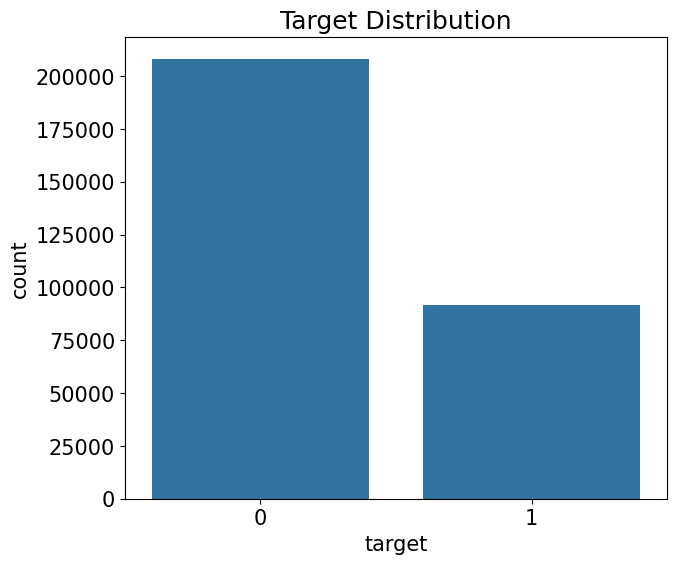

In [15]:
mpl.rc('font', size=15)
plt.figure(figsize=(7,6))

ax = sns.countplot(x='target', data=train)
ax.set_title('Target Distribution')

In [16]:
ax.patches #도형객체모두를담은리스트

<Axes.ArtistList of 2 patches>

In [17]:
rectangle = ax.patches[0]
rectangle.get_height()

np.float64(208236.0)

도형 위치 활용해서 주위에 텍스트 띄우거나 가능

In [18]:
rectangle.get_x() + rectangle.get_width()/2.0
#처음은0이긴한데다음패치들은잘나옴

np.float64(0.0)

In [19]:
rectangle.get_height() + len(train) * 0.001 #여백

np.float64(208536.0)

In [20]:
#x좌표 y좌표 아니..
def write_percent(ax, total_size):
    for patch in ax.patches:
        height = patch.get_height()
        width = patch.get_width()
        left_coord = patch.get_x()#도형왼쪽테두리x축위치 
        percent = height/total_size*100

        ax.text(x=left_coord + width/2.0, 
                y=height+total_size*0.001, 
                s=f'{percent:1.1f}%',
                ha='center') #ha는수평정렬하는
        #텍스트적는함수

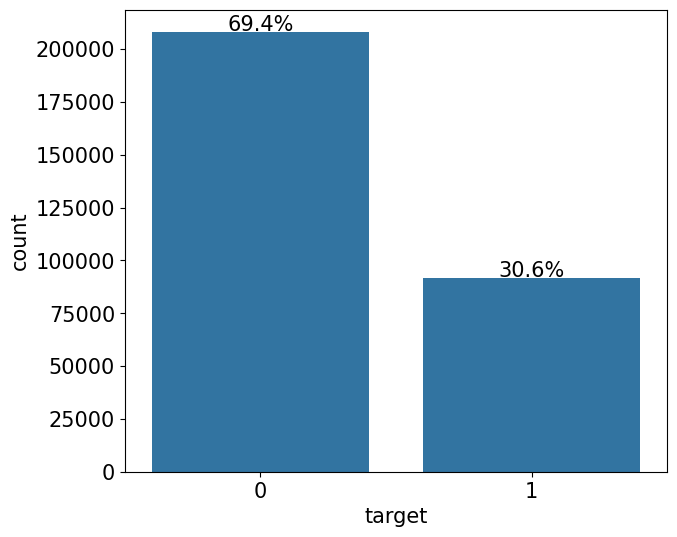

In [21]:
plt.figure(figsize=(7,6))

ax = sns.countplot(x='target', data=train)
write_percent(ax, len(train))

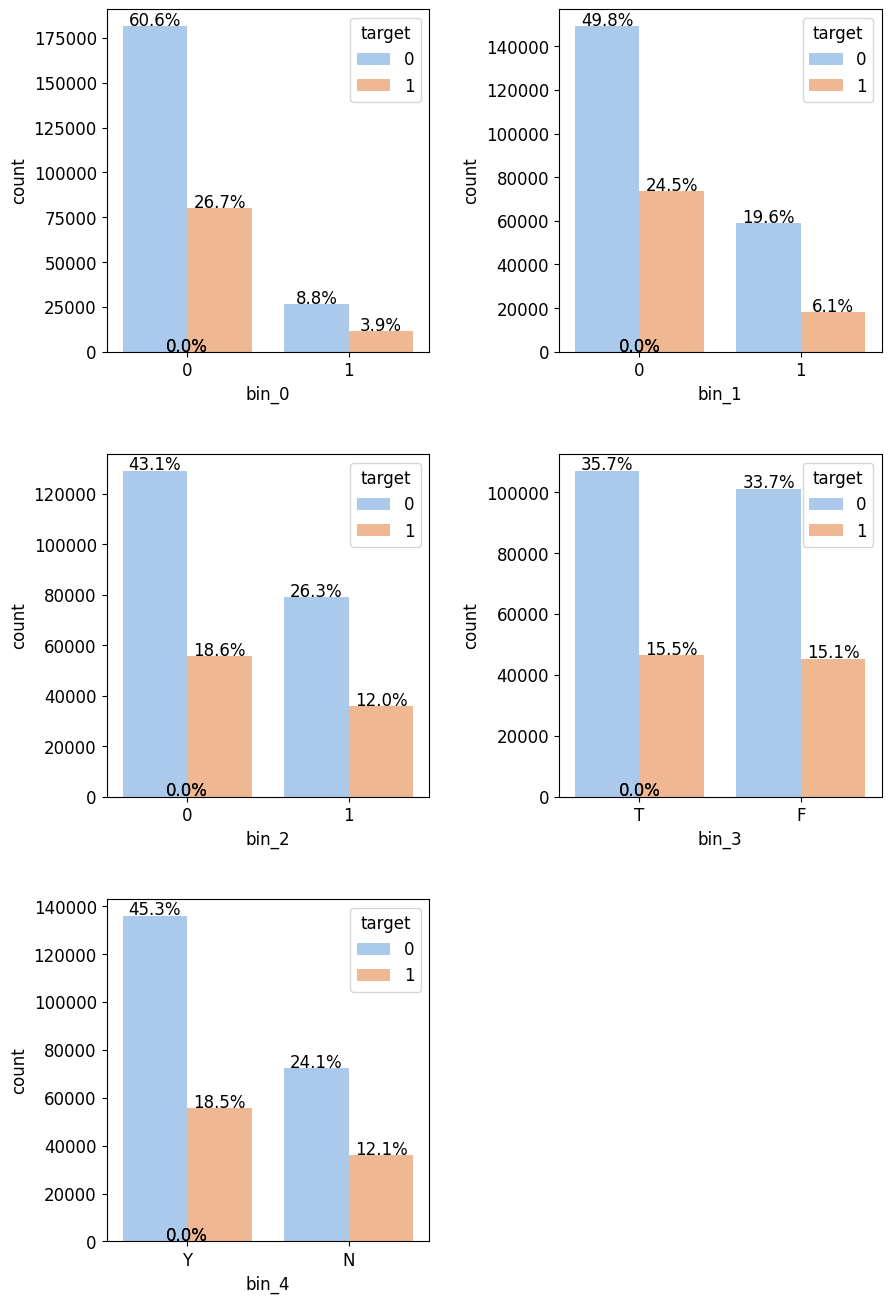

In [22]:
#각 이진 피처들과 그 타겟값들 간의 상관관계를 살피고 싶다면?

import matplotlib.gridspec as gridspec

mpl.rc('font', size=12)
grid = gridspec.GridSpec(3,2)
plt.figure(figsize=(10,16))
plt.subplots_adjust(wspace=0.4, hspace=0.3)

bin_features = ['bin_0', 'bin_1', 'bin_2', 'bin_3', 'bin_4']

for idx, feature in enumerate(bin_features): #enumerate : 인덱스까지 주는
    ax = plt.subplot(grid[idx])

    sns.countplot(x=feature,
                 data=train,
                 hue='target',
                 palette='pastel',
                 ax=ax)

    write_percent(ax, len(train))

교차분석표 : 범주형 데이터 2개를 비교 분석 시 사용, 각 범주형 데이터의 빈도나 통계량을 행과 열로 결합

아래에선 명목형 데이터 피처와 타깃값을 해당 범주형 데이터 2개로 여기고 비교 분석

In [23]:
pd.crosstab(train['nom_0'], train['target'])

target,0,1
nom_0,,
Blue,72914,23252
Green,85682,41659
Red,49640,26853


In [24]:
crosstab = pd.crosstab(train['nom_0'], train['target'], normalize='index') * 100
crosstab

target,0,1
nom_0,,
Blue,75.820976,24.179024
Green,67.285478,32.714522
Red,64.894827,35.105173


In [25]:
#피쳐가 열로 설정되어 (인덱스-볼드-가 아니라 열에 들어가 있어야) 있어야 그리기 편하다
crosstab = crosstab.reset_index()
crosstab

target,nom_0,0,1
0,Blue,75.820976,24.179024
1,Green,67.285478,32.714522
2,Red,64.894827,35.105173


In [26]:
def get_crosstab(df, feature):
    crosstab = pd.crosstab(df[feature], df['target'], normalize='index')*100
    crosstab = crosstab.reset_index()
    return crosstab

In [27]:
crosstab[1] #타깃값1에해당하는열

0    24.179024
1    32.714522
2    35.105173
Name: 1, dtype: float64

이걸 참고해서 기존 그래프 위에 pointplot을 덧대보자

In [28]:
def plot_pointplot(ax, feature, crosstab):
    ax2 = ax.twinx() #x축은 공유 y축은 공유하지 않는 새로운 축
    ax2 = sns.pointplot(x=feature, y=1, data=crosstab, 
                        order=crosstab[feature].values,
                       color='black',
                       legend=False)
    ax2.set_ylim(crosstab[1].min()-5, crosstab[1].max()*1.1)
    ax2.set_ylabel('Target 1 Ratio(%)')

모두 종합하면..

In [29]:
def plot_cat_dist_with_true_ratio(df, features, num_rows, num_cols, size=(15,20)):
    plt.figure(figsize=size)
    grid = gridspec.GridSpec(num_rows, num_cols)
    plt.subplots_adjust(wspace=0.45, hspace=0.3)

    for idx, feature in enumerate(features):
        ax = plt.subplot(grid[idx])
        crosstab = get_crosstab(df, feature)
    
        sns.countplot(x=feature, data=df, order=crosstab[feature].values, color='skyblue', ax=ax)
        write_percent(ax, len(df))
    
        plot_pointplot(ax, feature, crosstab)
    
        ax.set_title(f'{feature} distribution')

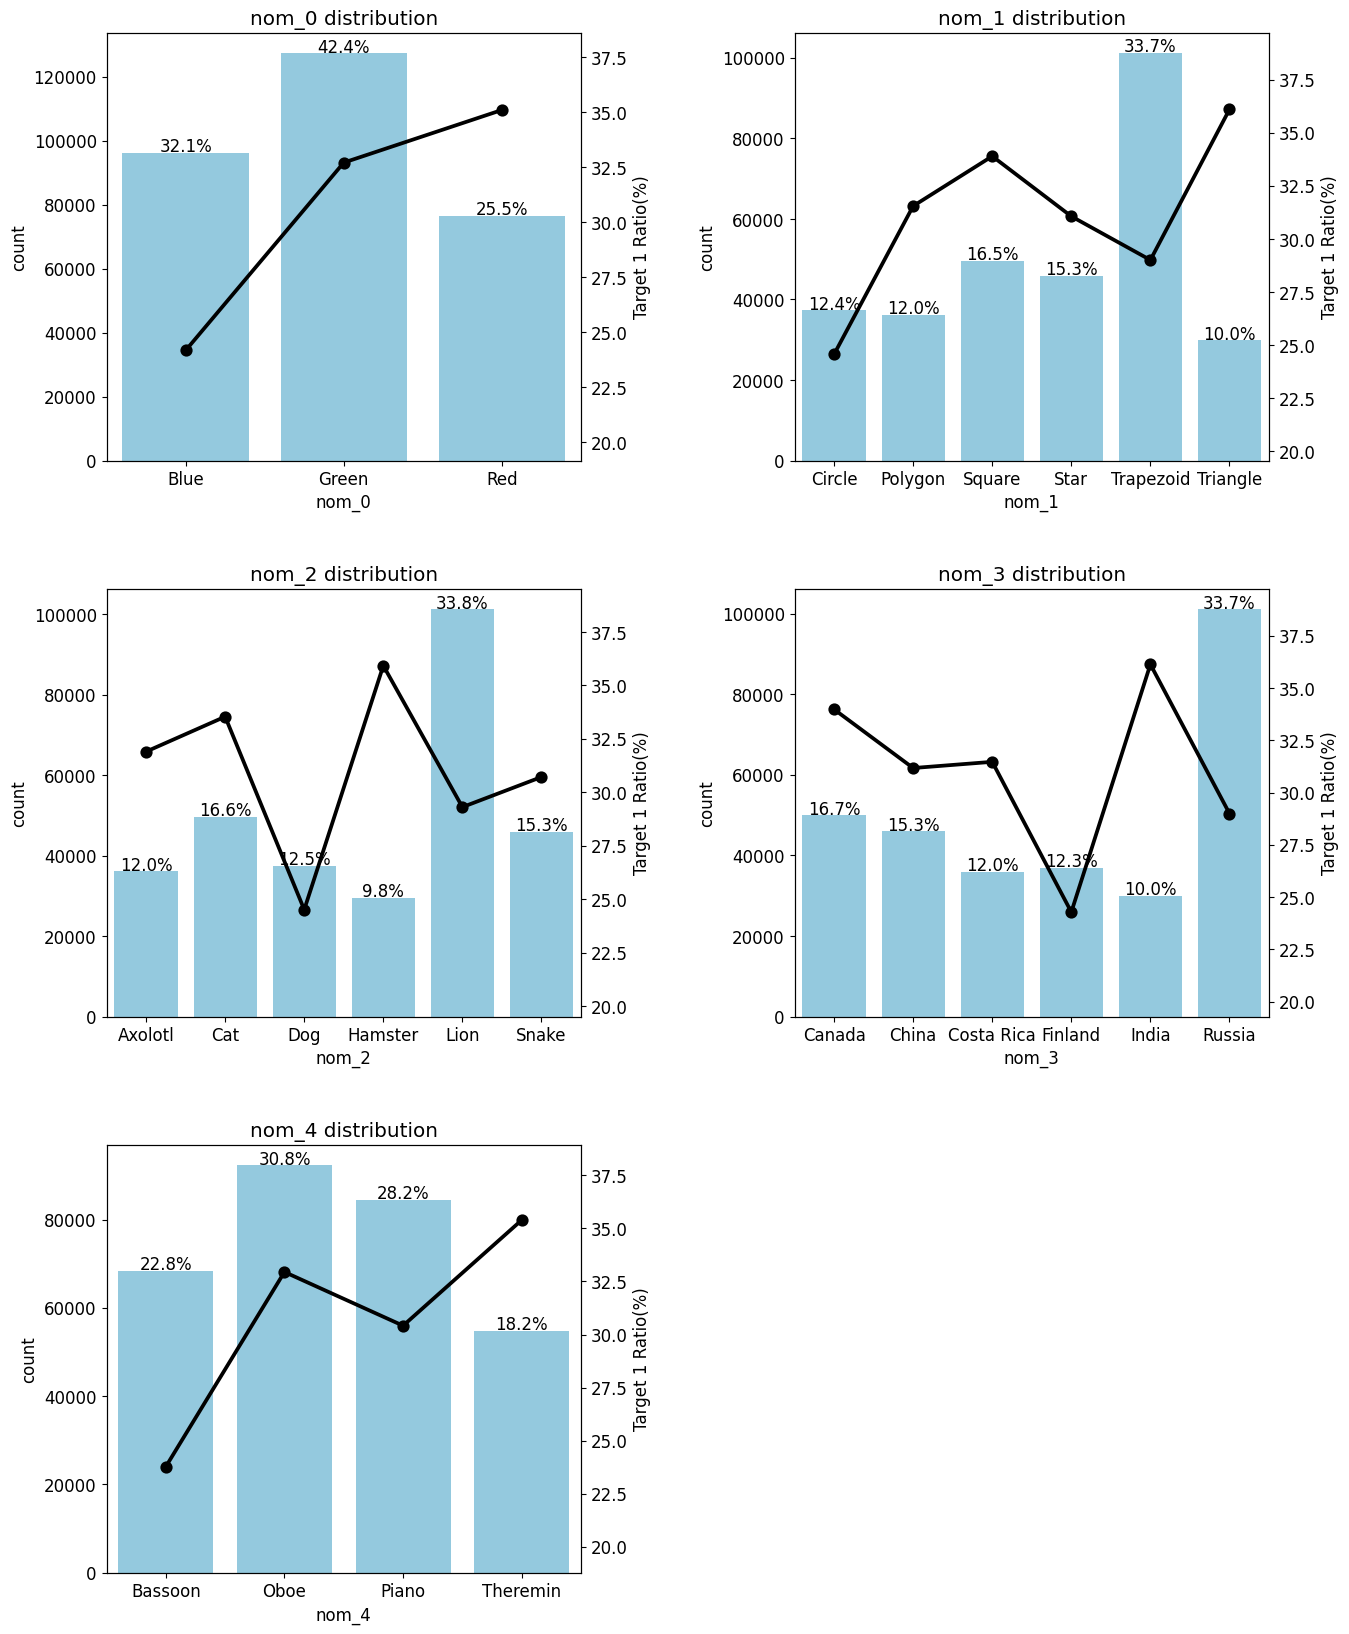

In [30]:
#시각화 할 명목형 피쳐들 설정
nom_features = ['nom_0', 'nom_1', 'nom_2', 'nom_3', 'nom_4']
plot_cat_dist_with_true_ratio(train, nom_features, num_rows=3, num_cols=2)

이번 시각화를 통해 : 각 피처의 시각화에서 고윳값별로 타깃값 1 비율이 서로 다르므로, 해당 피처들은 타깃값에 대한 예측 능력을 모두 가지고 있어 사용할 수 있다.

교차분석표 -> 카운트 플롯에 별도 y축으로 포인트플롯 올리기 -> 두개 섞기


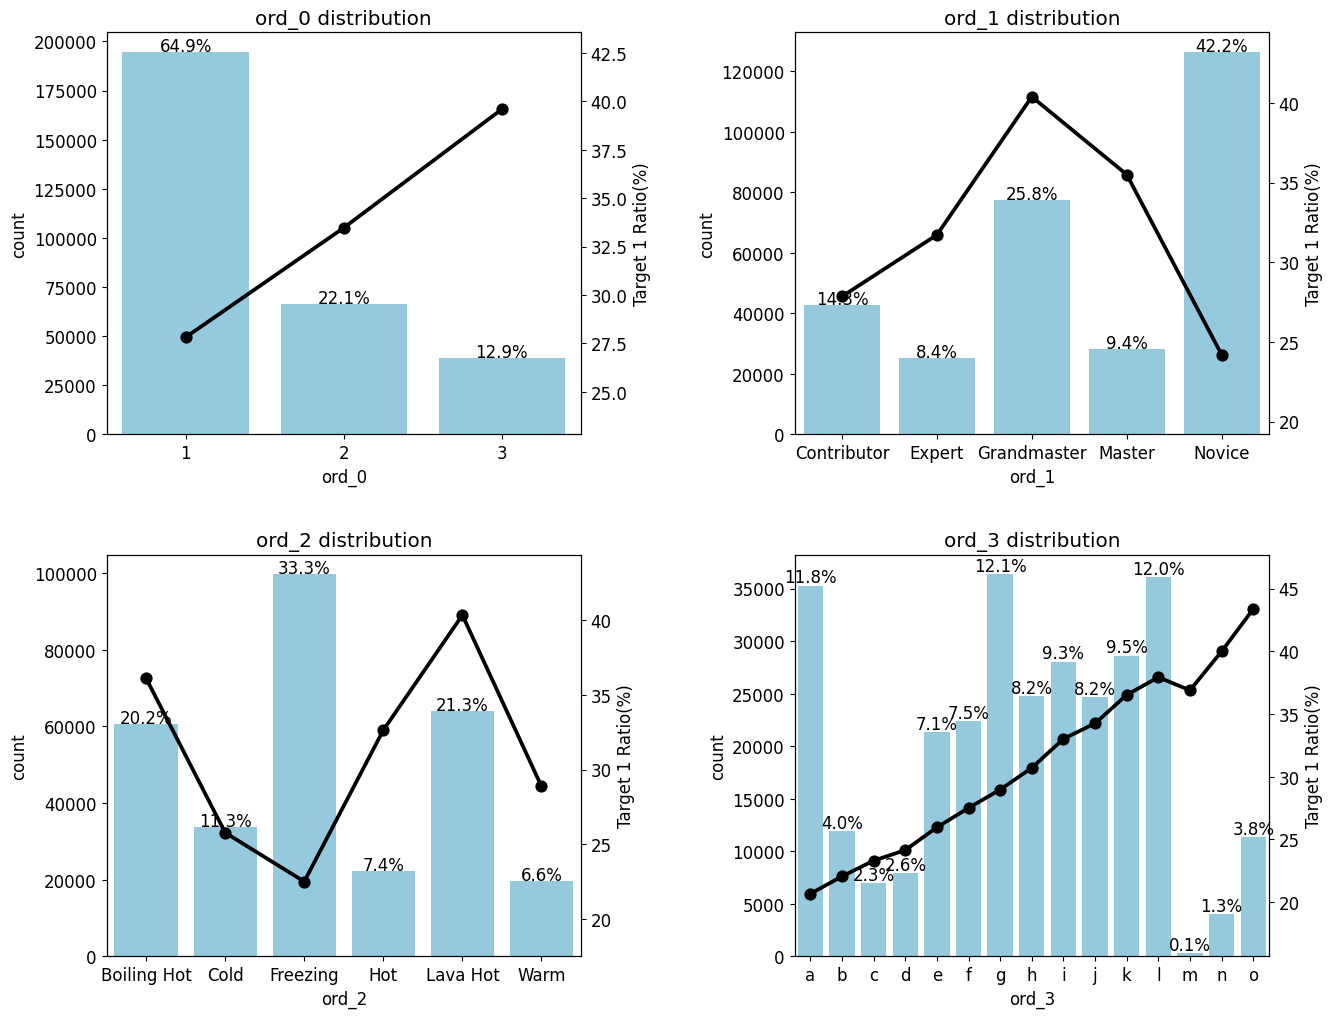

In [31]:
ord_features = ['ord_0','ord_1','ord_2','ord_3']
plot_cat_dist_with_true_ratio(train, ord_features, num_rows=2, num_cols=2, size=(15,12))

순서형 피처 : 별도의 순서를 지정하고 기억해줘야. 일단 지금 순서가 안맞음

In [32]:
#그래서 쓰는게...
from pandas.api.types import CategoricalDtype

ord_1_value =  ['Novice', 'Contributor', 'Expert', 'Master', 'Grandmaster']
ord_2_value = ['Freezing', 'Cold', 'Warm', 'Hot', 'Boiling Hot', 'Lava Hot']

ord_1_dtype = CategoricalDtype(categories=ord_1_value, ordered=True)
ord_2_dtype = CategoricalDtype(categories=ord_2_value, ordered=True)
#순서 강제

In [33]:
train['ord_1'] = train['ord_1'].astype(ord_1_dtype)
train['ord_2'] = train['ord_2'].astype(ord_2_dtype)

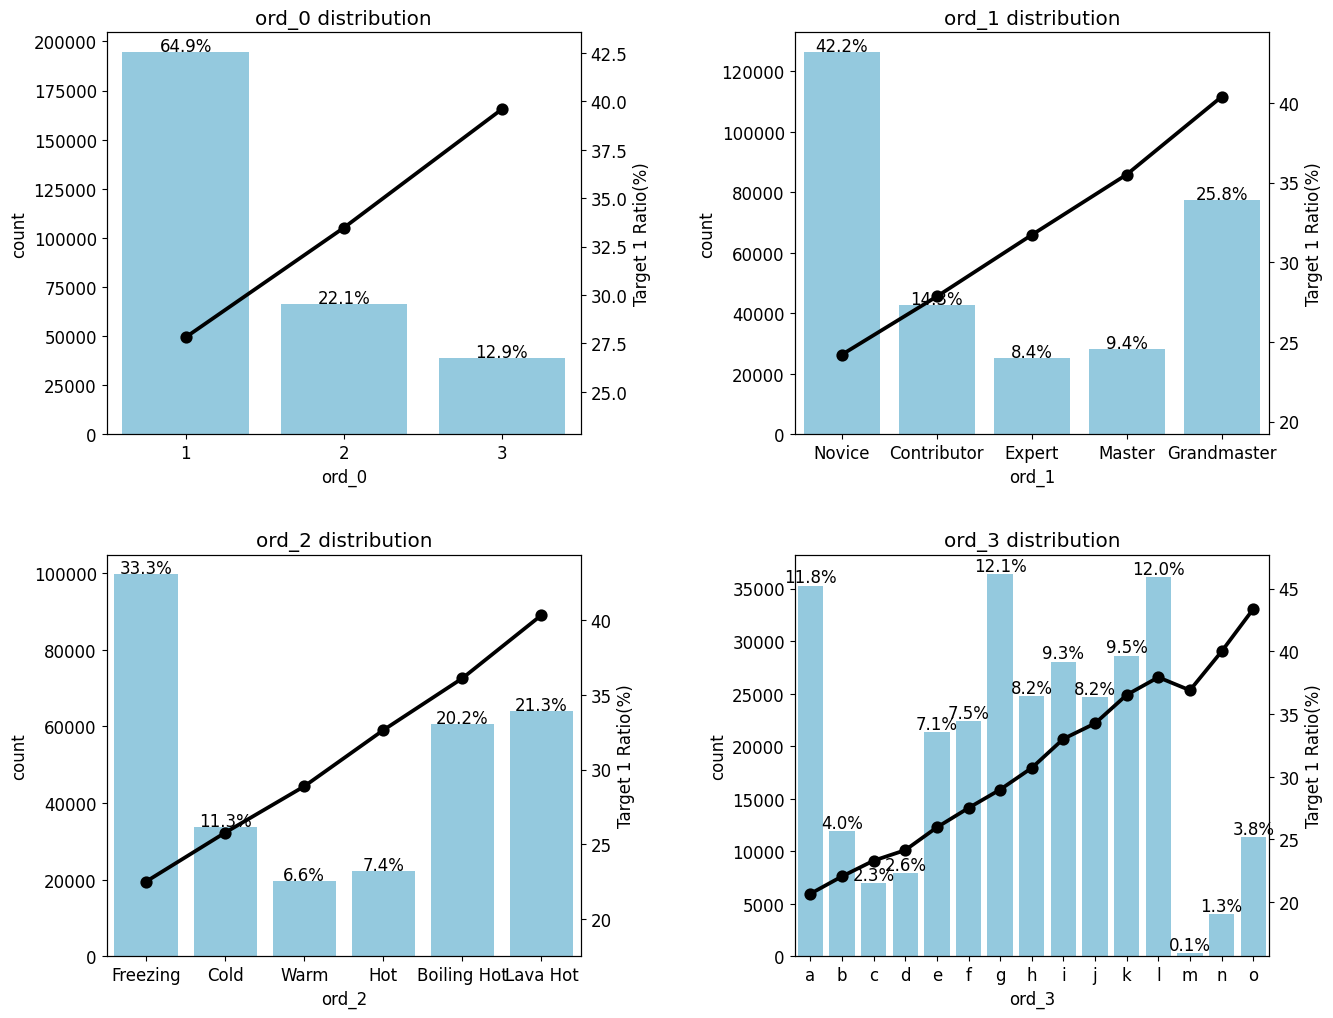

In [34]:
plot_cat_dist_with_true_ratio(train, ord_features, num_rows=2, num_cols=2, size=(15,12))

고윳값 순서에 따라 타깃값 1인 비율도 커짐

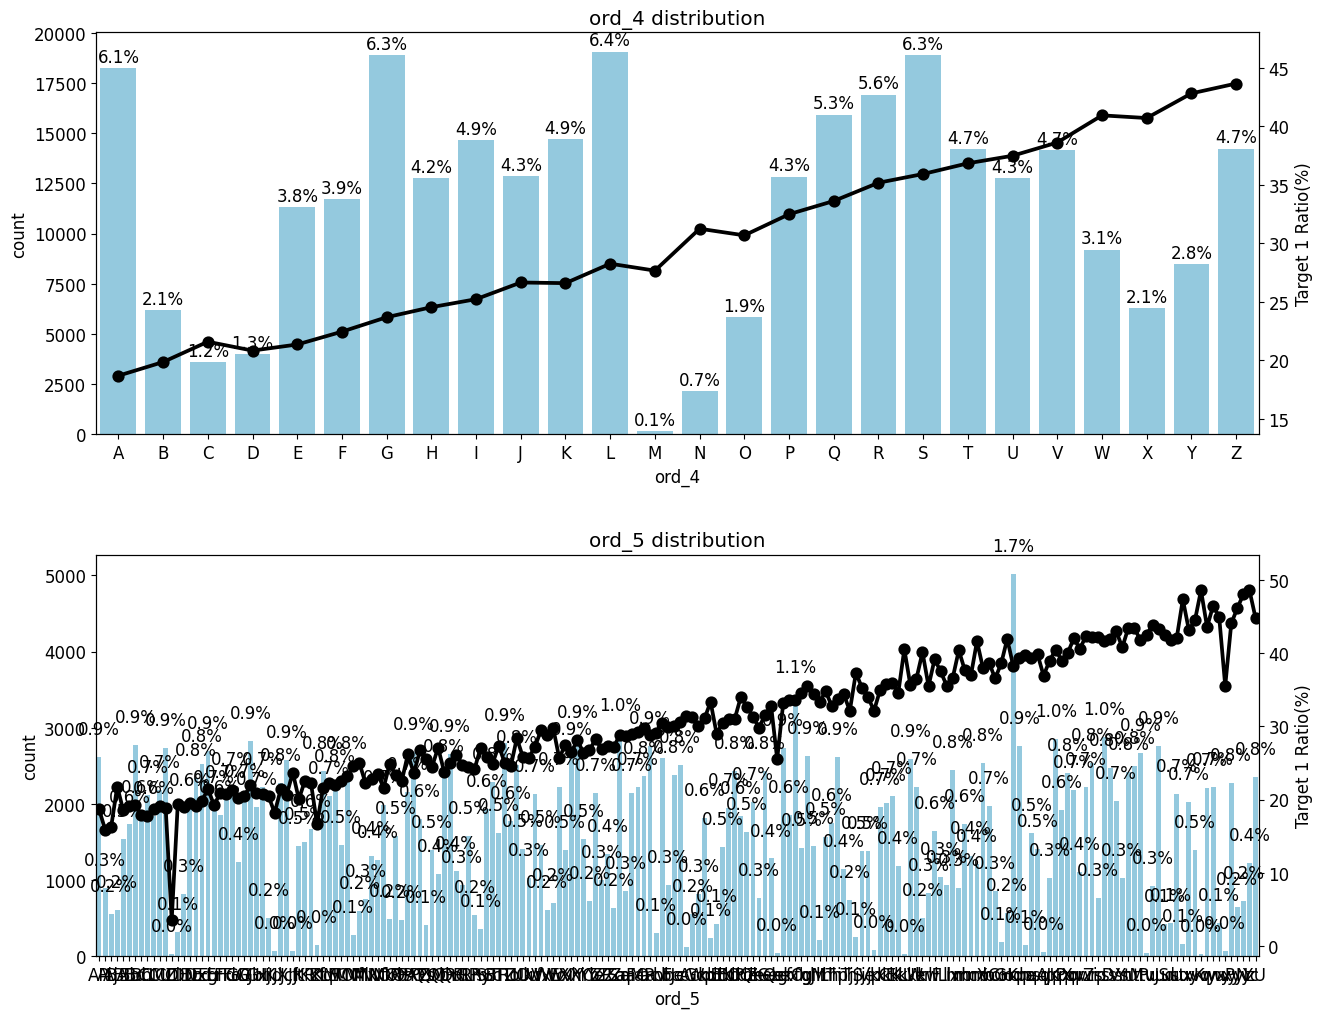

In [35]:
plot_cat_dist_with_true_ratio(train, ['ord_4', 'ord_5'], num_rows=2, num_cols=1, size=(15,12))

ord 4랑 5도...

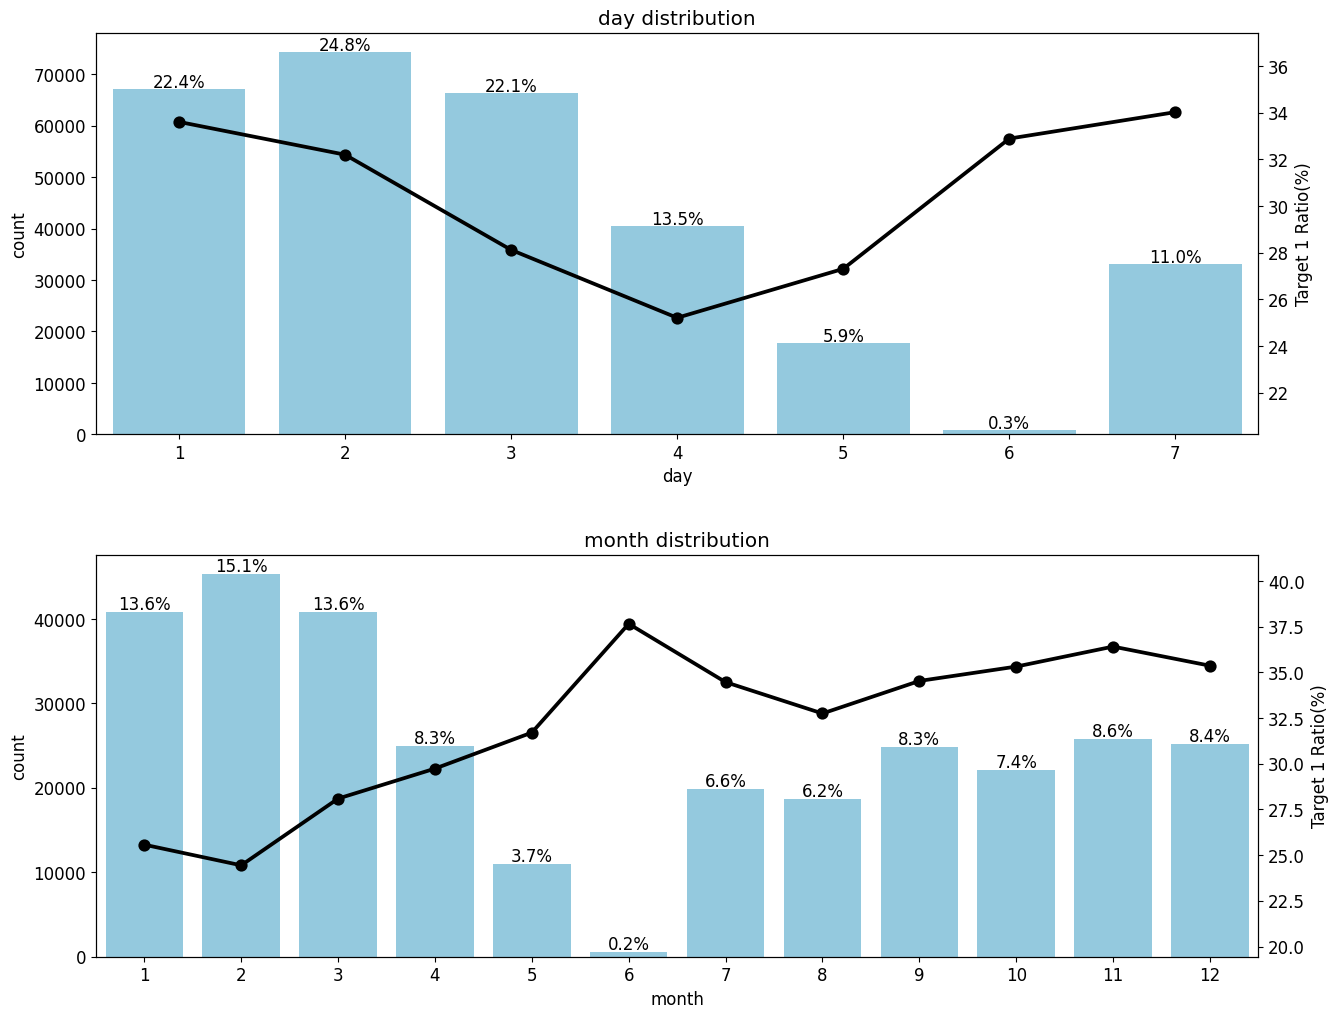

In [36]:
plot_cat_dist_with_true_ratio(train, ['day', 'month'], num_rows=2, num_cols=1, size=(15,12))

탐색적 데이터 분석 끝..

In [37]:
all_data = pd.concat([train, test])

In [38]:
all_data.head()

,bin_0,bin_1,bin_2,bin_3,bin_4,nom_0,nom_1,nom_2,nom_3,nom_4,...,nom_9,ord_0,ord_1,ord_2,ord_3,ord_4,ord_5,day,month,target
id,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,T,Y,Green,Triangle,Snake,Finland,Bassoon,...,2f4cb3d51,2,Grandmaster,Cold,h,D,kr,2,2,0.0
1,0,1,0,T,Y,Green,Trapezoid,Hamster,Russia,Piano,...,f83c56c21,1,Grandmaster,Hot,a,A,bF,7,8,0.0
2,0,0,0,F,Y,Blue,Trapezoid,Lion,Russia,Theremin,...,ae6800dd0,1,Expert,Lava Hot,h,R,Jc,7,2,0.0
3,0,1,0,F,Y,Red,Trapezoid,Snake,Canada,Oboe,...,8270f0d71,1,Grandmaster,Boiling Hot,i,D,kW,2,1,1.0
4,0,0,0,F,N,Red,Trapezoid,Lion,Canada,Oboe,...,b164b72a7,1,Grandmaster,Freezing,a,R,qP,7,8,0.0


In [39]:
all_data = all_data.drop('target', axis=1)

In [40]:
all_data.head()

,bin_0,bin_1,bin_2,bin_3,bin_4,nom_0,nom_1,nom_2,nom_3,nom_4,...,nom_8,nom_9,ord_0,ord_1,ord_2,ord_3,ord_4,ord_5,day,month
id,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,T,Y,Green,Triangle,Snake,Finland,Bassoon,...,c389000ab,2f4cb3d51,2,Grandmaster,Cold,h,D,kr,2,2
1,0,1,0,T,Y,Green,Trapezoid,Hamster,Russia,Piano,...,4cd920251,f83c56c21,1,Grandmaster,Hot,a,A,bF,7,8
2,0,0,0,F,Y,Blue,Trapezoid,Lion,Russia,Theremin,...,de9c9f684,ae6800dd0,1,Expert,Lava Hot,h,R,Jc,7,2
3,0,1,0,F,Y,Red,Trapezoid,Snake,Canada,Oboe,...,4ade6ab69,8270f0d71,1,Grandmaster,Boiling Hot,i,D,kW,2,1
4,0,0,0,F,N,Red,Trapezoid,Lion,Canada,Oboe,...,cb43ab175,b164b72a7,1,Grandmaster,Freezing,a,R,qP,7,8


In [41]:
#텍스트를 원핫인코딩해서 머신 러닝 되게 해보자
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()
all_data_encoded = encoder.fit_transform(all_data)
all_data.head()

,bin_0,bin_1,bin_2,bin_3,bin_4,nom_0,nom_1,nom_2,nom_3,nom_4,...,nom_8,nom_9,ord_0,ord_1,ord_2,ord_3,ord_4,ord_5,day,month
id,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,T,Y,Green,Triangle,Snake,Finland,Bassoon,...,c389000ab,2f4cb3d51,2,Grandmaster,Cold,h,D,kr,2,2
1,0,1,0,T,Y,Green,Trapezoid,Hamster,Russia,Piano,...,4cd920251,f83c56c21,1,Grandmaster,Hot,a,A,bF,7,8
2,0,0,0,F,Y,Blue,Trapezoid,Lion,Russia,Theremin,...,de9c9f684,ae6800dd0,1,Expert,Lava Hot,h,R,Jc,7,2
3,0,1,0,F,Y,Red,Trapezoid,Snake,Canada,Oboe,...,4ade6ab69,8270f0d71,1,Grandmaster,Boiling Hot,i,D,kW,2,1
4,0,0,0,F,N,Red,Trapezoid,Lion,Canada,Oboe,...,cb43ab175,b164b72a7,1,Grandmaster,Freezing,a,R,qP,7,8


In [42]:
#인코딩 공동 적용 다 했으니까
num_train = len(train)
X_train = all_data_encoded[:num_train]
X_test = all_data_encoded[num_train:]

y = train['target'] #정답지 백업

이렇게 훈련 데이터와 테스트 데이터는 행 번호로 명확히 나눌 수 있어서 상관 없는데, 훈련 데이터와 검증 데이터를 나눌 때는 다양한 파라미터로 나눌 수 있으므로 별도의 함수를 사용

훈련 데이터 (Training Data):모델이 정답과 패턴을 직접 학습하는 데이터입니다.AI가 공부하는 교과서와 같습니다.

검증 데이터 (Validation Data):학습 중인 모델의 성능을 중간 평가하고 옵션을 수정(튜닝)하는 데이터입니다.모의고사와 같습니다. 가장 좋은 모델을 고르는 데 씁니다.

테스트 데이터 (Test Data):모든 학습이 끝난 후 모델의 최종 실력을 평가하는 데이터입니다.학습 과정에서 절대 보여주지 않으며, 실제 수능 시험과 같습니다.

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X_train, y, 
                                                    test_size=0.1, #아래 2개는 나중에 설명
                                                    stratify=y, 
                                                    random_state=10) #시드

test_size : 값이 정수면 검증 데이터의 갯수, 실수면 비율 <- 오..

stratify : 이 파라미터로 지정한 값을 '공정하게' 배분하겠다. 즉 타깃값이 훈련 데이터와 검증 데이터에 같은 비율로 포함되게끔..

In [44]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [45]:
logistic_model.predict_proba(X_valid) #타깃값 별 그것일 확률 : predict_proba

array([[0.23046657, 0.76953343],
       [0.91343642, 0.08656358],
       [0.82500326, 0.17499674],
       ...,
       [0.24947081, 0.75052919],
       [0.49539942, 0.50460058],
       [0.95751856, 0.04248144]])

In [46]:
logistic_model.predict(X_valid)

array([1, 0, 0, ..., 1, 1, 0])

In [47]:
y_valid_preds = logistic_model.predict_proba(X_valid)[:, 1] #probad 예측 결과의 두번째 열 (인덱스상1)

In [48]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_valid, y_valid_preds)

print(f'검증 데이터 ROC AUC : {roc_auc:.4f}')

검증 데이터 ROC AUC : 0.7970


In [49]:
y_preds = logistic_model.predict_proba(X_test)[:, 1]

In [50]:
submission['target'] = y_preds
submission.to_csv('submissionn.csv')